In [1]:
import numpy as np
import matplotlib.pyplot as plt


**Ejercicio 6.** Notamos $y$ a la cantidad de individuos de una población de animales silvestres. Supongamos que $y$ se rige por una ecuación de la forma:

$$
\dot{y}(t)=r(t)y(t)\left(1-\frac{y(t)}{K}\right)-my(t),
\qquad
y(0)=y_0,
$$

donde

$$
r(t)=0{,}2+0{,}2\cos(2\pi t), \qquad K=1000 \qquad \text{y} \qquad m=0{,}1.
$$

(a) Interpretar el significado de $r(t)$, $K$ y $m$.

(b) Estimar la evolución de la población a lo largo de $50$ años, utilizando el siguiente esquema, debido a Heun:

$$
y_{i+1}
=
y_i+\frac{h}{4}\left\{
f(t_i,y_i)+3f\left(t_i+\frac{2}{3}h,\,
y_i+\frac{2}{3}h\,f(t_i,y_i)\right)
\right\}.
$$

Debe medir el tiempo en años, y tomar un paso temporal $h=\frac{1}{365}$ (un día).

(c) Graficar, superpuestas, las soluciones al problema con los valores iniciales $y_0=100$, $y_0=500$ y $y_0=1000$.

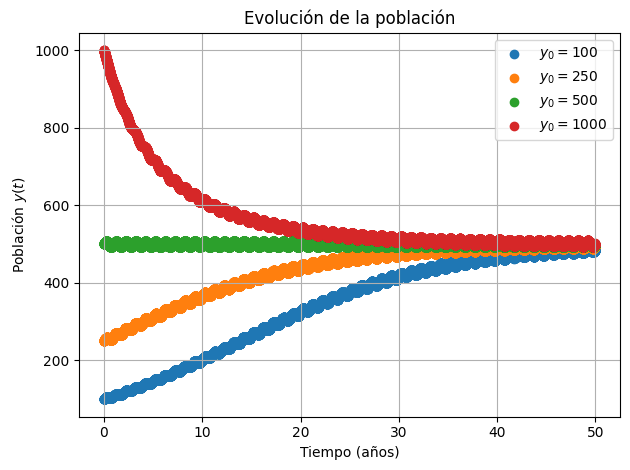

In [8]:
# Ejercicio 6

# y(t) = cantidad de individuos de una población de animales silvestres
# r(t) = 0.2 + 0.2 * cos(2*pi*t)
# K = 1000
# m = 0.1
# y0 = ??

def Heun(K, m, t0, tf, y0, h):

    def r(t):
        return 0.2 + 0.2 * np.cos(2*np.pi*t)
    
    def f(t, y):
        return r(t) * y * (1 - y/K) - m * y
    
    t_valores = [t0]
    y_valores = [y0]

    t_actual = t0
    y_actual = y0

    while t_actual < tf:
        y_actual = y_actual + h/4 * (f(t_actual, y_actual) + 3*f(t_actual+ 2/3*h, y_actual + 2/3*h * f(t_actual, y_actual)))
        t_actual = t_actual + h 

        t_valores.append(t_actual)
        y_valores.append(y_actual)


    return np.array(t_valores), np.array(y_valores)


poblacion_inicial = [100, 250, 500, 1000]

for y0 in poblacion_inicial:
    tiempos, y = Heun(K=1000, m=0.1, t0=0, tf=50, y0=y0, h=1/365)
    plt.scatter(tiempos, y,label=f"$y_0={y0}$")
    

plt.grid(True)
plt.xlabel("Tiempo (años)")
plt.ylabel("Población $y(t)$")
plt.title("Evolución de la población")
plt.legend()
plt.tight_layout()
plt.show()